In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import neural_utils as neural
from mpl_toolkits import mplot3d

In [2]:
# boundary data (t,x)

N_b = 100

x_0 = torch.cat([torch.rand(50,1), torch.zeros(50,1)] , dim = 1)
x_1 = torch.cat([torch.rand(50,1), torch.ones(50,1)], dim = 1)

x_b = torch.cat([x_0,x_1], dim = 0)
u_b = torch.zeros(100,1)


# initial data

x_init = torch.cat([torch.zeros(50,1),torch.rand(50,1)], dim = 1)
u_init = torch.sin(torch.pi * x_init[:, 1:])



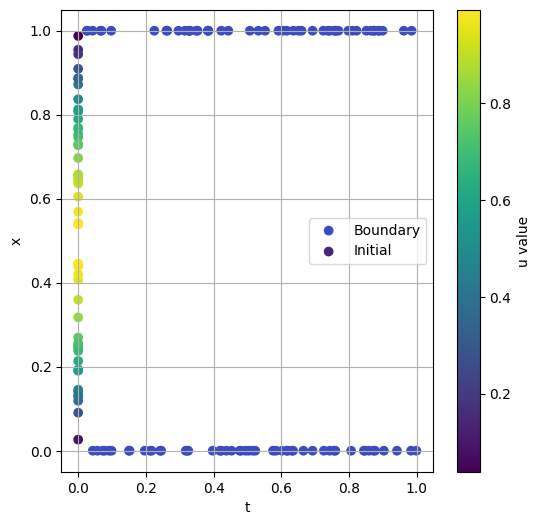

In [3]:
# boundary points
t_b = x_b[:, 0].detach().numpy()
x_b_vals = x_b[:, 1].detach().numpy()

# initial points
t_init = x_init[:, 0].detach().numpy()
x_init_vals = x_init[:, 1].detach().numpy()

plt.figure(figsize=(6,6))

plt.scatter(t_b, x_b_vals, c=u_b.numpy(), cmap='coolwarm', label="Boundary")
plt.scatter(t_init, x_init_vals, c=u_init.detach().numpy(), cmap='viridis', label="Initial")

plt.colorbar(label="u value")
plt.xlabel("t")
plt.ylabel("x")
plt.legend()
plt.grid()

plt.show()

In [4]:
model = neural.FCN(2,1, 10,5)

model

FCN(
  (fcs): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Tanh()
  )
  (fch): Sequential(
    (0): Sequential(
      (0): Linear(in_features=10, out_features=10, bias=True)
      (1): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=10, out_features=10, bias=True)
      (1): Tanh()
    )
    (2): Sequential(
      (0): Linear(in_features=10, out_features=10, bias=True)
      (1): Tanh()
    )
    (3): Sequential(
      (0): Linear(in_features=10, out_features=10, bias=True)
      (1): Tanh()
    )
  )
  (fce): Linear(in_features=10, out_features=1, bias=True)
)

In [5]:
def make_heat_1d_residual(alpha):

    def residual_fn(X, u, grad_u):
        u_t = grad_u[:, 0:1]
        u_x = grad_u[:, 1:2]

        u_xx = neural.gradients(u_x, X)[:, 1:2]

        return u_t - alpha * u_xx

    return residual_fn

residual_fn = make_heat_1d_residual(0.1)

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X_data = torch.cat([x_b,x_init], dim = 0)
U_data = torch.cat([u_b, u_init], dim=0)

neural.train(50000, optimizer, X_data, U_data, model, residual_fn, 1, 2, 1000)

0 0.3323255181312561 0.33232036232948303 5.167120434634853e-06
1000 0.11024340242147446 0.10654711723327637 0.0036962858866900206
2000 0.10651267319917679 0.10257686674594879 0.003935805056244135
3000 0.06352314352989197 0.05465228855609894 0.00887085497379303
4000 0.007514983415603638 0.003706767223775387 0.0038082164246588945
5000 0.0023221380542963743 0.001006211619824171 0.0013159264344722033
6000 0.0002680080942809582 5.6652956118341535e-05 0.00021135514543857425
7000 0.00014396281039807945 2.3420956495101564e-05 0.00012054185208398849
8000 0.00010893838771153241 2.0079138266737573e-05 8.885924762580544e-05
9000 8.42130248202011e-05 1.902361327665858e-05 6.518940790556371e-05
10000 7.310043292818591e-05 2.110900095431134e-05 5.199143197387457e-05
11000 6.598111940547824e-05 2.2554802853846923e-05 4.3426316551631317e-05
12000 6.26904729870148e-05 2.264975591970142e-05 4.0040718886302784e-05
13000 6.042849054210819e-05 2.4056233087321743e-05 3.637225745478645e-05
14000 5.82280590606

([0.3323255181312561,
  0.3313978314399719,
  0.3304727375507355,
  0.32955020666122437,
  0.3286302983760834,
  0.3277129530906677,
  0.3267982602119446,
  0.3258861005306244,
  0.3249766230583191,
  0.3240698575973511,
  0.32316577434539795,
  0.3222644627094269,
  0.3213658332824707,
  0.3204699754714966,
  0.31957682967185974,
  0.31868648529052734,
  0.3177989423274994,
  0.3169141411781311,
  0.31603217124938965,
  0.3151529133319855,
  0.31427639722824097,
  0.3134026825428009,
  0.31253159046173096,
  0.3116632401943207,
  0.3107976019382477,
  0.3099345266819,
  0.3090740442276001,
  0.3082161247730255,
  0.30736076831817627,
  0.3065078854560852,
  0.30565741658210754,
  0.3048093616962433,
  0.30396366119384766,
  0.3031202256679535,
  0.3022790253162384,
  0.30144003033638,
  0.3006032705307007,
  0.2997685372829437,
  0.2989358901977539,
  0.29810526967048645,
  0.29727664589881897,
  0.2964498996734619,
  0.29562512040138245,
  0.29480212926864624,
  0.29398101568222046,


In [7]:
def analytic_solution(x,t):
    return torch.exp(-0.1 * torch.pi**2 * t) * torch.sin(torch.pi * x)

(100, 100)
(100, 100)


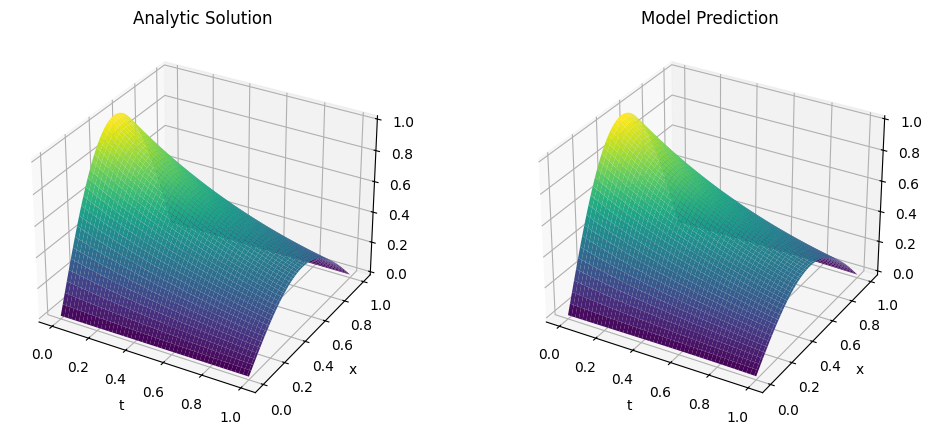

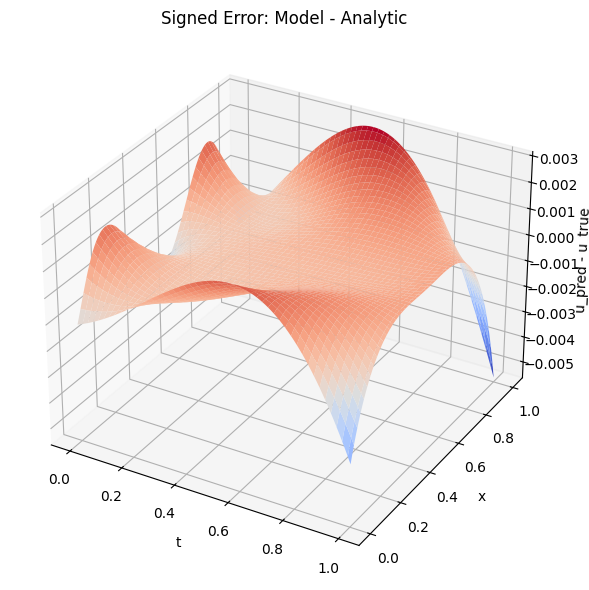

In [ ]:
# create mesh

N = 100

t = torch.linspace(0, 1, N)
x = torch.linspace(0, 1, N)

T, X = torch.meshgrid(t, x, indexing='ij')  # shape (N, N)

# flatten for model input
u_true = analytic_solution(X, T).detach().cpu().numpy()

model.eval()

data = torch.stack([T.reshape(-1), X.reshape(-1)], dim=1)
with torch.no_grad():
    u_pred = model(data).reshape(N, N).cpu().numpy()

T_np = T.numpy()
X_np = X.numpy()

fig = plt.figure(figsize=(12,5))
# --- analytic ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T_np, X_np, u_true, cmap='viridis')
ax1.set_title("Analytic Solution")
ax1.set_xlabel("t")
ax1.set_ylabel("x")

# --- model ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(T_np, X_np, u_pred, cmap='viridis')
ax2.set_title("Model Prediction")
ax2.set_xlabel("t")
ax2.set_ylabel("x")
plt.show()


diff = u_pred - u_true

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(T_np, X_np, diff, cmap="coolwarm")

ax.set_title("Signed Error: Model - Analytic")
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.set_zlabel("u_pred - u_true")

plt.tight_layout()
plt.show()

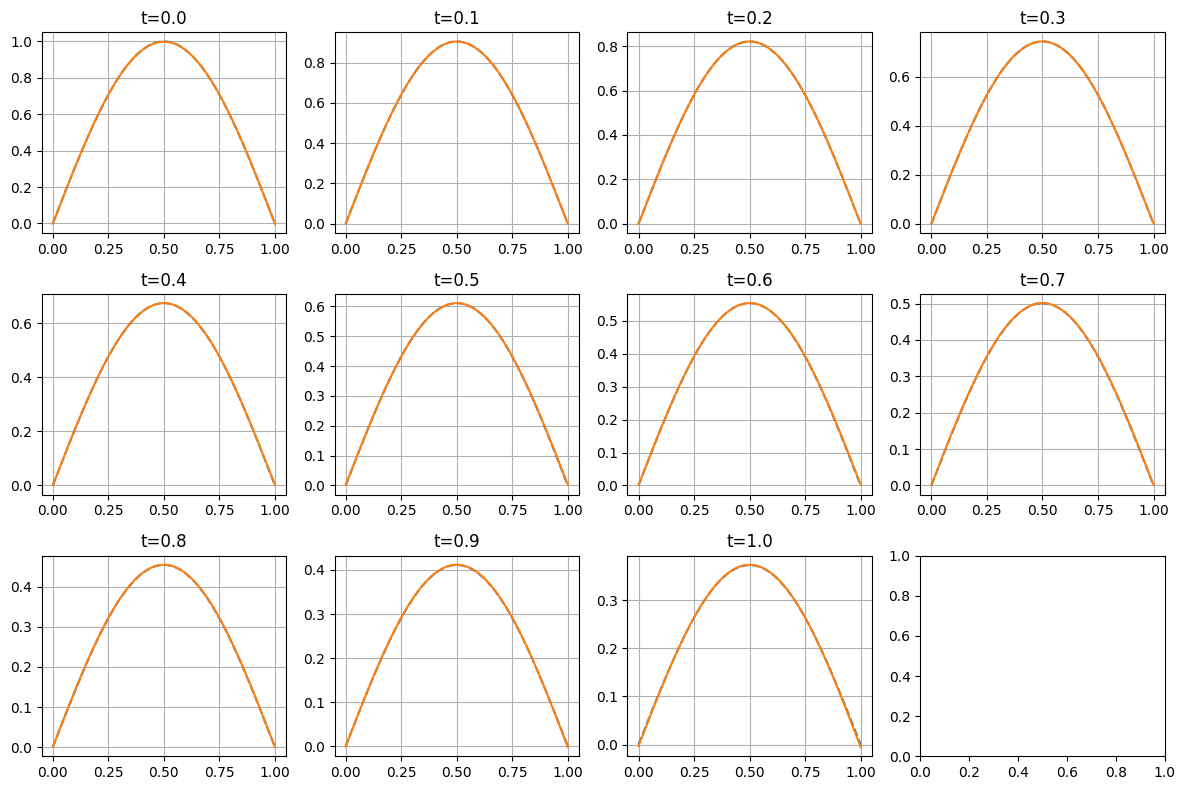

In [17]:
N_x = 200
x = torch.linspace(0, 1, N_x).reshape(-1,1)

t_slices = torch.linspace(0, 1, 11) 

model.eval()

fig, axes = plt.subplots(3, 4, figsize=(12,8))
axes = axes.flatten()

for i, t_val in enumerate(t_slices):
    ax = axes[i]

    t = torch.full_like(x, t_val)
    TX = torch.cat([t, x], dim=1)

    with torch.no_grad():
        u_pred = model(TX)

    u_true = torch.exp(-0.1 * torch.pi**2 * t) * torch.sin(torch.pi * x)

    ax.plot(x, u_true, '--', label='true')
    ax.plot(x, u_pred, '-', label='pred')

    ax.set_title(f"t={t_val:.1f}")
    ax.grid()

plt.tight_layout()
plt.show()

0 nan 0.4361112415790558 nan
1000 nan 0.08061251044273376 nan
2000 nan 0.061196085065603256 nan
3000 nan 0.047528959810733795 nan
4000 nan 0.008020392619073391 nan
5000 nan 0.0017039092490449548 nan
6000 nan 0.0007101697847247124 nan
7000 nan 0.0004029077826999128 nan
8000 nan 0.0001906957768369466 nan
9000 nan 8.926466398406774e-05 nan
10000 nan 4.8814450565259904e-05 nan
11000 nan 3.5753830161411315e-05 nan
12000 nan 2.609720831969753e-05 nan
13000 nan 1.7312147974735126e-05 nan
14000 nan 1.0925230526481755e-05 nan
15000 nan 7.259170615725452e-06 nan
16000 nan 5.414922270574607e-06 nan
17000 nan 4.27160239269142e-06 nan
18000 nan 3.4159709230152657e-06 nan
19000 nan 2.7750074877985753e-06 nan
20000 nan 2.2618091861659195e-06 nan
21000 nan 1.8628826410349575e-06 nan
22000 nan 1.5734152611912577e-06 nan
23000 nan 1.405052557856834e-06 nan
24000 nan 2.1486600871867267e-06 nan
25000 nan 1.0145965916308342e-06 nan
26000 nan 8.885141369319172e-07 nan
27000 nan 7.84272003784281e-07 nan
2800

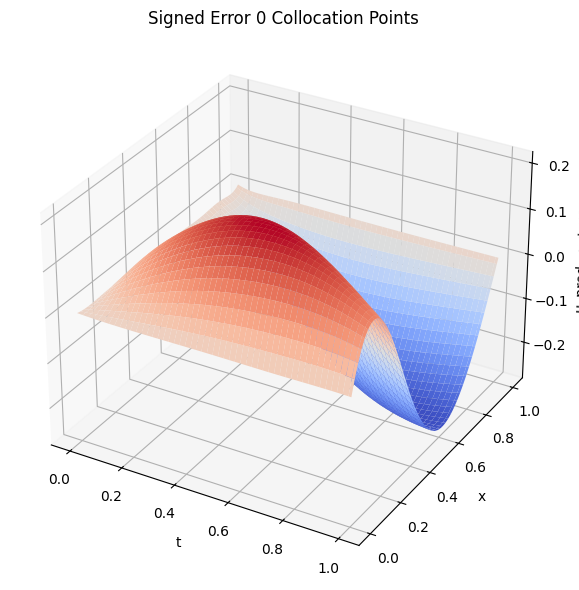

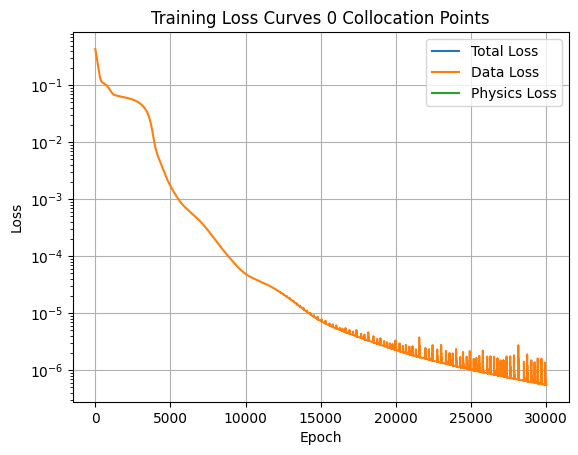

0 0.11447399109601974 0.11429140716791153 0.00018258029012940824
1000 0.08793284744024277 0.08504432439804077 0.002888526301831007
2000 0.07776737958192825 0.02923184633255005 0.048535533249378204
3000 0.016861356794834137 0.016677774488925934 0.00018358266970608383
4000 0.010761957615613937 0.007867072708904743 0.002894884441047907
5000 0.013080676086246967 0.004594017751514912 0.008486658334732056
6000 0.005407433956861496 0.0031536335591226816 0.0022538001649081707
7000 0.0052294558845460415 0.0026079057715833187 0.0026215501129627228
8000 0.004508670419454575 0.002291593234986067 0.0022170774172991514
9000 0.005150188226252794 0.001708741532638669 0.0034414466936141253
10000 0.0015715169720351696 0.001571389497257769 1.2747172206672985e-07
11000 0.0025722081772983074 0.0012008209014311433 0.0013713872758671641
12000 0.0024962211027741432 0.0009156673913821578 0.0015805537113919854
13000 0.0008414020412601531 0.0007647786405868828 7.6623386121355e-05
14000 0.0006101905601099133 0.00

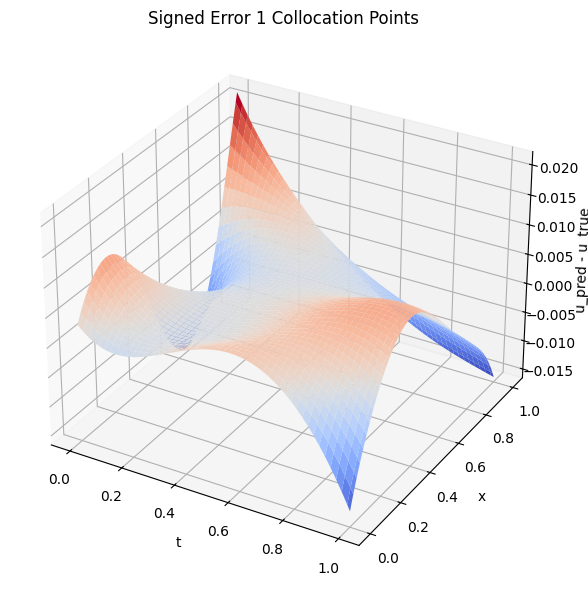

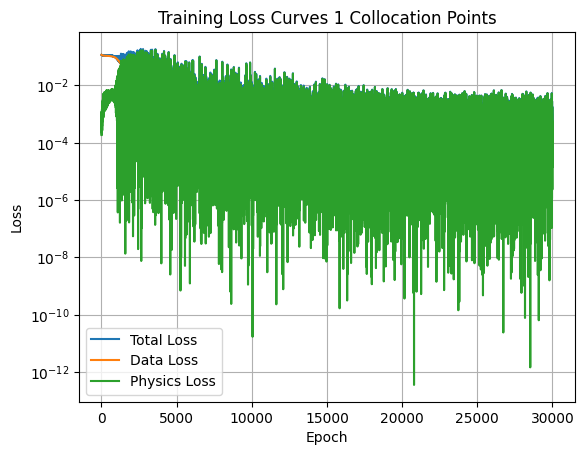

0 0.19672611355781555 0.19667693972587585 4.918111517326906e-05
1000 0.10631243884563446 0.10161061584949493 0.004701819270849228
2000 0.022992726415395737 0.015849649906158447 0.007143076509237289
3000 0.009434916079044342 0.0048286039382219315 0.004606312606483698
4000 0.005528301931917667 0.0028590825386345387 0.002669219160452485
5000 0.002695249393582344 0.0013035826850682497 0.0013916668249294162
6000 0.001266408246010542 0.0005308470572344959 0.0007355611305683851
7000 0.0005425125127658248 0.00021653925068676472 0.00032597329118289053
8000 0.0005226156790740788 0.00011787541006924585 0.00040474027628079057
9000 0.0003266859275754541 7.738441490801051e-05 0.0002493015199434012
10000 0.00018099350563716143 5.0546146667329594e-05 0.00013044735533185303
11000 0.0001229049521498382 3.842838850687258e-05 8.447656728094444e-05
12000 8.257738954853266e-05 3.120967812719755e-05 5.1367711421335116e-05
13000 7.192284101620317e-05 2.77797498711152e-05 4.414309296407737e-05
14000 8.29406490

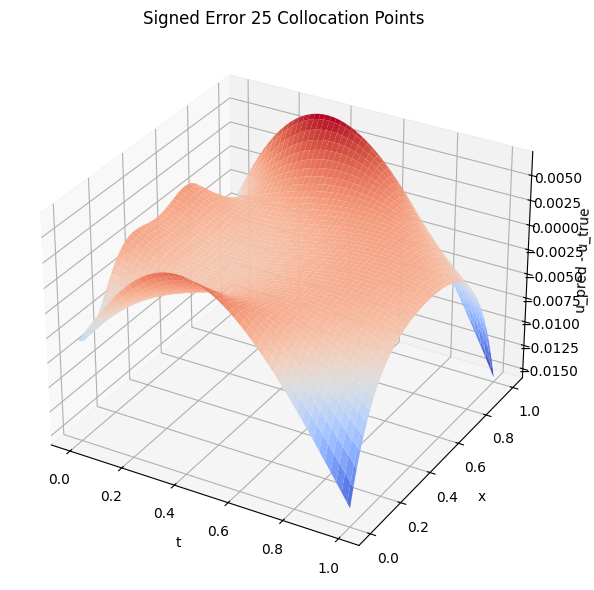

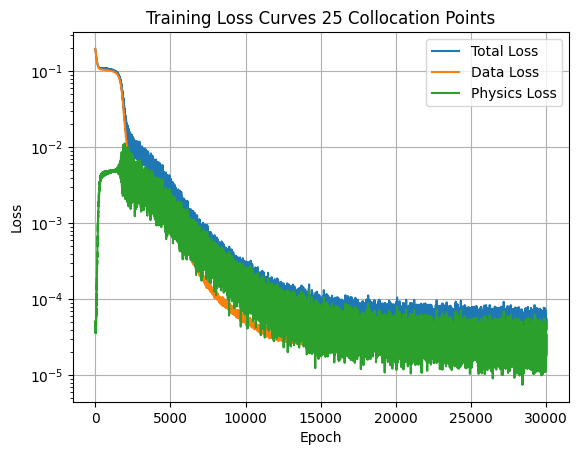

0 0.11859449744224548 0.11854074895381927 5.3750289225718006e-05
1000 0.10071855783462524 0.094899982213974 0.005818571895360947
2000 0.008785472251474857 0.007781010586768389 0.001004461315460503
3000 0.006227758713066578 0.004690058063715696 0.0015377007657662034
4000 0.0042594680562615395 0.0030893355142325163 0.0011701327748596668
5000 0.0029981215484440327 0.0019445584621280432 0.0010535630863159895
6000 0.0021711348090320826 0.0010200690012425184 0.0011510658077895641
7000 0.001370696467347443 0.0004765395715367049 0.0008941569249145687
8000 0.0008381686639040709 0.00023921325919218361 0.0005989554338157177
9000 0.0007743074093014002 0.0001145090936915949 0.0006597983301617205
10000 0.000461431045550853 6.784912693547085e-05 0.0003935819258913398
11000 0.0002740824711509049 5.175103433430195e-05 0.00022233143681660295
12000 0.0001536630152259022 4.4707918277708814e-05 0.00010895509331021458
13000 0.0001243097212864086 4.175075810053386e-05 8.255895954789594e-05
14000 7.8471057349

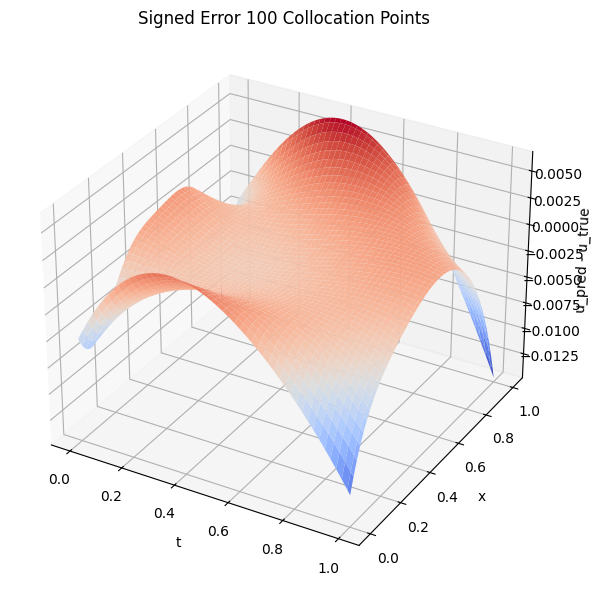

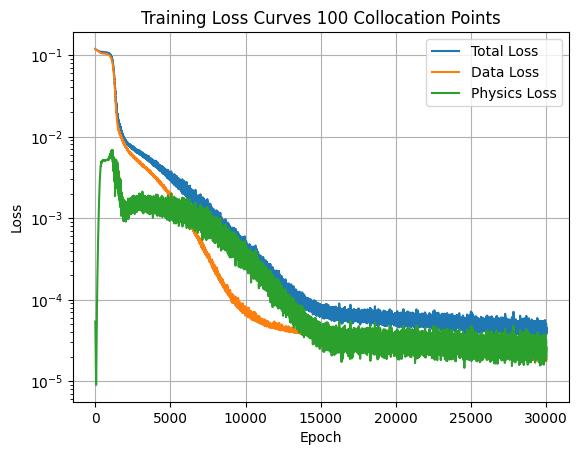

0 0.14303529262542725 0.14291736483573914 0.00011792439181590453
1000 0.10762536525726318 0.10308011621236801 0.004545251838862896
2000 0.0179312564432621 0.011040300130844116 0.006890956778079271
3000 0.004001529887318611 0.0015444292221218348 0.0024571006651967764
4000 0.001562234596349299 0.00047181188710965216 0.0010904227383434772
5000 0.0006364765577018261 0.00014043142437003553 0.0004960451042279601
6000 0.0003605190140660852 9.307704749517143e-05 0.0002674419665709138
7000 0.00027834277716465294 6.990081601543352e-05 0.0002084419538732618
8000 0.00021467095939442515 5.478630555444397e-05 0.00015988465747796
9000 0.00016706451424397528 4.5426095311995596e-05 0.00012163841165602207
10000 0.00012885556498076767 3.568752799765207e-05 9.31680406210944e-05
11000 0.00012181334022898227 2.6064068151754327e-05 9.574927389621735e-05
12000 9.814633085625246e-05 2.0587460312526673e-05 7.755887054372579e-05
13000 8.174258255166933e-05 1.6270978449028917e-05 6.547160592162982e-05
14000 7.354

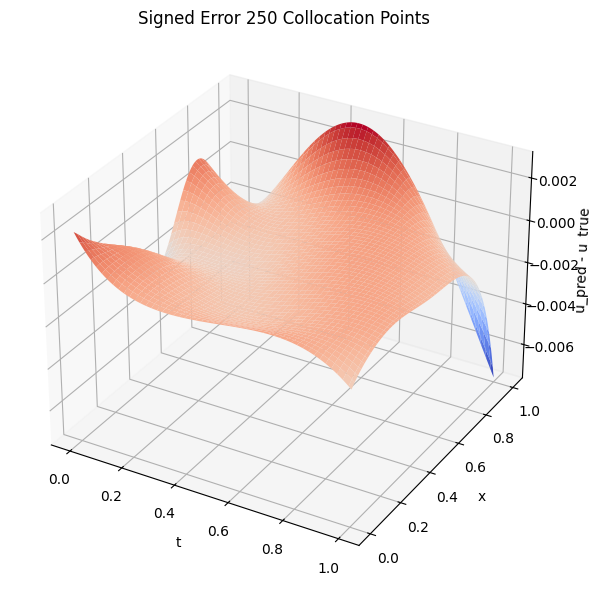

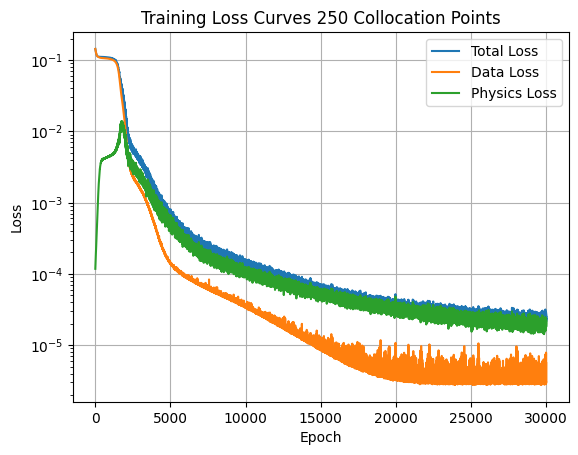

0 0.1638498306274414 0.16382937133312225 2.0459028746699914e-05
1000 0.10943853855133057 0.10384951531887054 0.005589023232460022
2000 0.10554090887308121 0.09963430464267731 0.005906606558710337
3000 0.011252897791564465 0.006766661070287228 0.004486236721277237
4000 0.002578692277893424 0.0010107222478836775 0.0015679700300097466
5000 0.0005924338474869728 0.00010126279084943235 0.0004911710857413709
6000 0.00020728542585857213 3.388319964869879e-05 0.00017340222257189453
7000 0.00015646166866645217 2.999962271132972e-05 0.00012646205141209066
8000 0.00010889071563724428 2.2477184757008217e-05 8.641352906124666e-05
9000 9.410984785063192e-05 1.9444856661721133e-05 7.466498936992139e-05
10000 6.990926340222359e-05 1.659622648730874e-05 5.3313040552893654e-05
11000 5.7941797422245145e-05 1.5748511941637844e-05 4.21932854806073e-05
12000 4.6158598706824705e-05 1.4903987903380767e-05 3.125461080344394e-05
13000 4.0793536754790694e-05 1.4935058061382733e-05 2.5858480512397364e-05
14000 3.

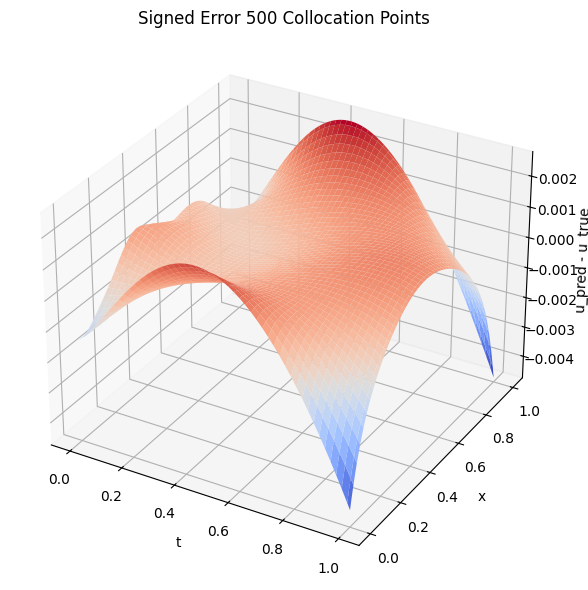

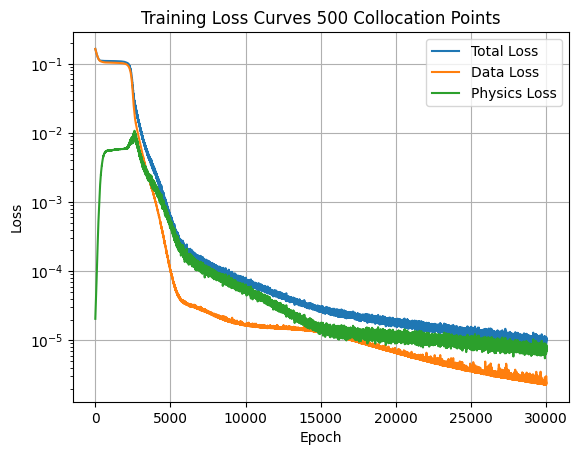

0 0.19692498445510864 0.19692136347293854 3.6253611597203417e-06
1000 0.10923721641302109 0.1053355485200882 0.003901665098965168
2000 0.05376361310482025 0.048463091254234314 0.005300520919263363
3000 0.006873981095850468 0.005430035758763552 0.0014439455699175596
4000 0.0030518770217895508 0.001311543514020741 0.001740333391353488
5000 0.001169868279248476 0.0003946351644117385 0.0007752330857329071
6000 0.0003783457796089351 0.0001127198338508606 0.0002656259457580745
7000 0.00015472969971597195 4.0217193600255996e-05 0.00011451250611571595
8000 9.431746730115265e-05 1.949155193869956e-05 7.482591172447428e-05
9000 7.599997479701415e-05 1.2706444067589473e-05 6.329353345790878e-05
10000 5.596496339421719e-05 1.0068576557387132e-05 4.589638774632476e-05
11000 5.22584086866118e-05 8.8611350292922e-06 4.3397274566814303e-05
12000 4.14292371715419e-05 8.064560461207293e-06 3.336467852932401e-05
13000 4.260442437953316e-05 7.19687204764341e-06 3.54075527866371e-05
14000 3.971808837377466

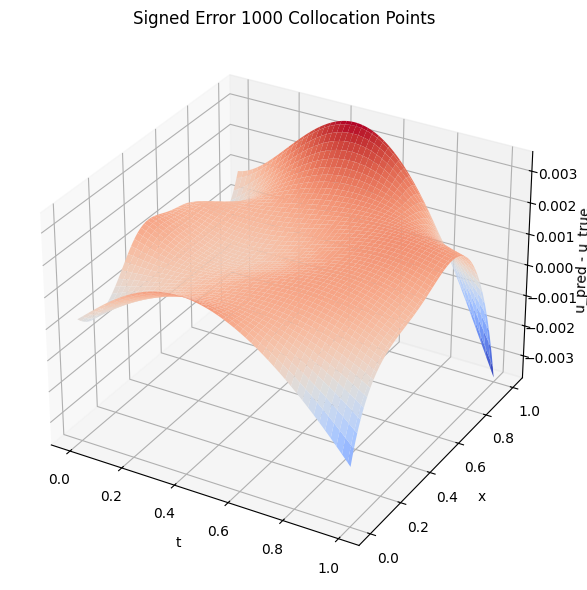

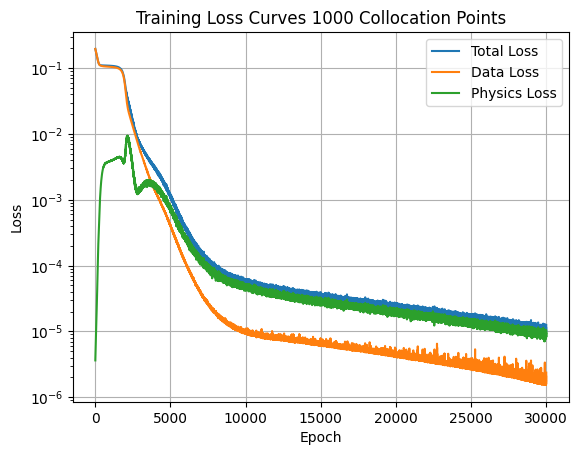

0 0.12169405817985535 0.12111176550388336 0.0005822925013490021
1000 0.10533566027879715 0.10027329623699188 0.0050623659044504166
2000 0.0096866050735116 0.007232944015413523 0.0024536612909287214
3000 0.0041192444041371346 0.002337201964110136 0.0017820425564423203
4000 0.00229140417650342 0.0009158801985904574 0.0013755240943282843
5000 0.0009433759842067957 0.0002505479787942022 0.000692827976308763
6000 0.0002744157100096345 7.357221329584718e-05 0.00020084349671378732
7000 0.00011741231719497591 5.225719360169023e-05 6.515512359328568e-05
8000 8.449646702501923e-05 4.423309292178601e-05 4.0263377741212025e-05
9000 7.372476102318615e-05 3.9409689634339884e-05 3.4315067750867456e-05
10000 6.696103082504123e-05 3.5089728044113144e-05 3.187129914294928e-05
11000 6.338451930787414e-05 3.280734381405637e-05 3.0577175493817776e-05
12000 6.112059054430574e-05 3.073109473916702e-05 3.038949398614932e-05
13000 5.652807158185169e-05 2.792941995721776e-05 2.8598653443623334e-05
14000 5.32746

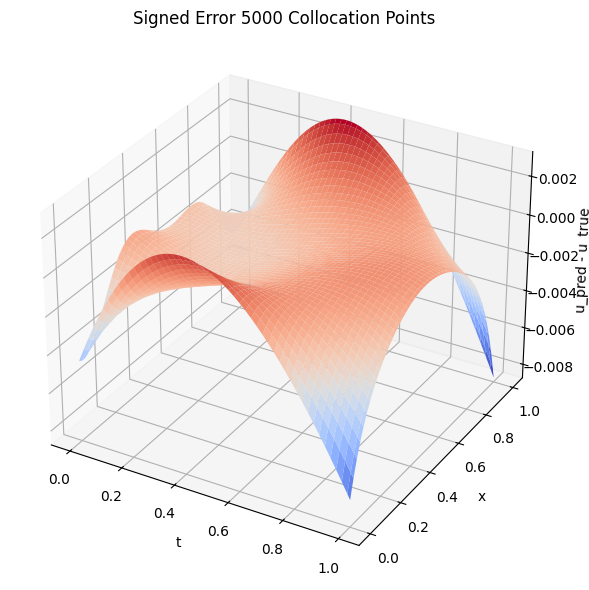

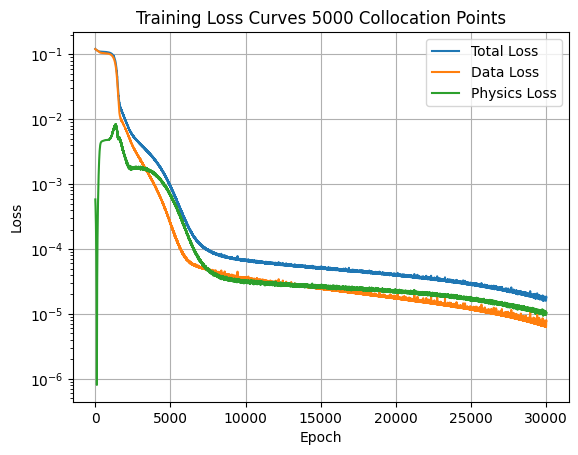

0 0.15943177044391632 0.15940342843532562 2.8348735213512555e-05
1000 0.11016973108053207 0.10576511174440384 0.004404619801789522
2000 0.08217988163232803 0.07609429955482483 0.0060855853371322155
3000 0.00400268379598856 0.0023971479386091232 0.0016055357409641147
4000 0.0012978804297745228 0.0006896091508679092 0.0006082712789066136
5000 0.00039992312667891383 0.00020379833586048335 0.0001961248053703457
6000 0.00021904680761508644 7.697818364249542e-05 0.0001420686166966334
7000 0.00015580574108753353 3.911110252374783e-05 0.0001166946385637857
8000 0.00012009523925371468 2.6953626729664393e-05 9.314161434303969e-05
9000 0.00010076944454340264 2.2588557840208523e-05 7.818088488420472e-05
10000 8.721577614778653e-05 1.971843266801443e-05 6.74973416607827e-05
11000 7.815995195414871e-05 1.8240258214063942e-05 5.991969010210596e-05
12000 7.076707697706297e-05 1.6789672372397035e-05 5.3977404604665935e-05
13000 6.410552305169404e-05 1.623256684979424e-05 4.7872959839878604e-05
14000 5.

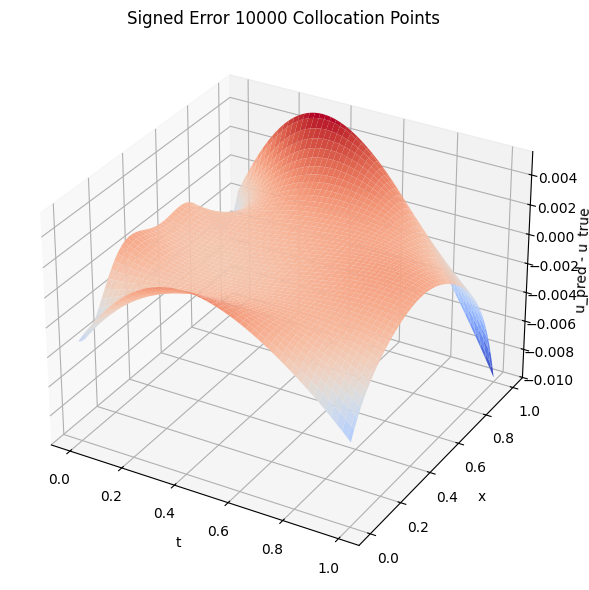

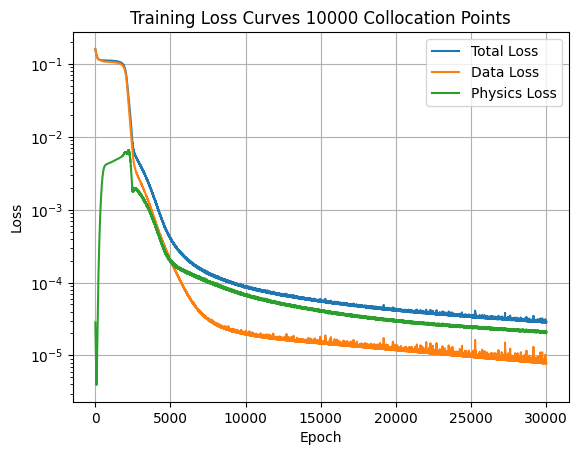

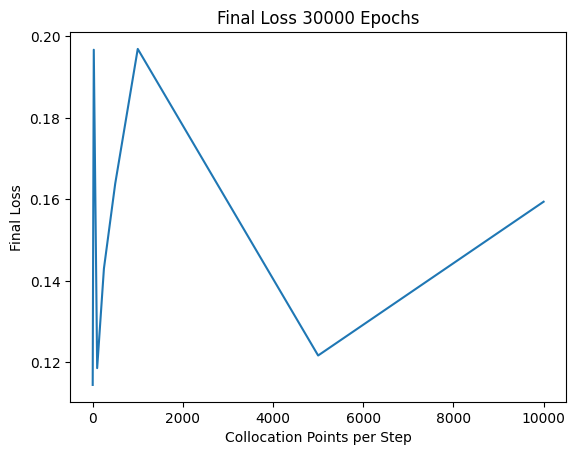

In [ ]:
# test collocation points

test = [0, 1, 25, 100, 250, 500, 1000, 5000, 10000]
results = []

seed = 0

torch.manual_seed(seed)
np.random.seed(seed)

u_true = analytic_solution(X, T).detach().cpu().numpy()

for n in test:
    
    test_model = neural.FCN(2,1, 10,5)
    optimizer = torch.optim.Adam(test_model.parameters(), lr=1e-4)
    losses, losses_data, losses_phys = neural.train(
        30000, optimizer, X_data, U_data, test_model,
        residual_fn, 1, 2, n
    )

    final_loss = losses[0]

    results.append(final_loss)

    test_model.eval()

    # plot error surface

    data = torch.stack([T.reshape(-1), X.reshape(-1)], dim=1)
    with torch.no_grad():
        u_pred = test_model(data).reshape(N, N).cpu().numpy()
    print(u_pred.shape)
    print(u_true.shape)
    diff = u_pred - u_true

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(T_np, X_np, diff, cmap="coolwarm")

    ax.set_title(f"Signed Error {n} Collocation Points")
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    ax.set_zlabel("u_pred - u_true")

    plt.tight_layout()
    plt.show()

    # training curves

    epochs = range(len(losses))

    plt.plot(epochs, losses, label='Total Loss')
    plt.plot(epochs, losses_data, label='Data Loss')
    plt.plot(epochs, losses_phys, label='Physics Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss Curves {n} Collocation Points')

    plt.yscale('log')
    plt.legend()
    plt.grid()

    plt.show()
    
plt.plot(test, results)
plt.xlabel('Collocation Points per Step')
plt.ylabel('Final Loss')
plt.title('Final Loss 30000 Epochs')
plt.show()